Istanze valide per l'addestramento: 3882

Avvio della 10-Fold Cross-Validation con Random Forest...

✅ RISULTATI 10-FOLD CV:
Accuratezza Media: 34.85%
Deviazione Standard: +/- 1.82%

Calcolo feature importance medie sui 10 fold...

📊 Top 10 feature più importanti (media su CV):
     feature  mean_importance       std
1          a         0.077636  0.002740
9         f2         0.075595  0.003384
12   n_facts         0.071063  0.002398
8         f1         0.071005  0.005755
0          r         0.070462  0.002725
15       c_r         0.069224  0.003937
11    f_horn         0.068648  0.006627
14  f_constr         0.068119  0.004022
13  f_normal         0.065351  0.004665
4      r_a_3         0.063592  0.005328

File salvato in: /kaggle/working/feature_importance_cv.csv

📊 Confusion Matrix:
[[420 241  41 120  69   0]
 [135 362  75  86 112  33]
 [ 94 106 301 109 151 132]
 [124 119  93 109 100  48]
 [ 64 135 117  85 159  91]
 [  2   2  19   6  20   2]]


<Figure size 640x480 with 0 Axes>

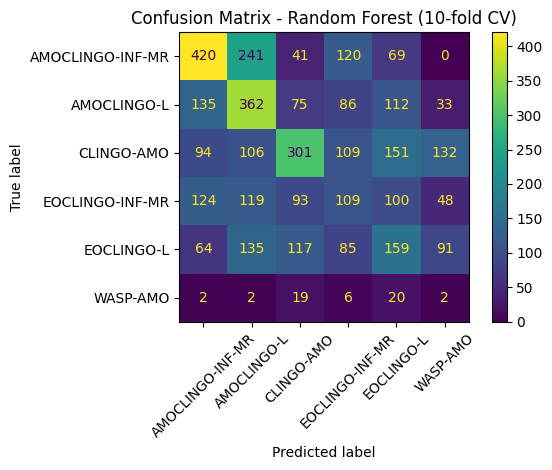

In [1]:
# Dataset with measp feature (the only preprocessing applied is the removing not solved instances)
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings

warnings.filterwarnings('ignore')  


csv_path = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/measp/training_dataset_measp.csv'


if csv_path == '':
    raise FileNotFoundError("No CSV file found in /kaggle/input")

df = pd.read_csv(csv_path)


df_clean = df[df['best_config'] != 'TIMEOUT']

X = df_clean.drop(columns=['domain', 'instance_name', 'best_config', 'min_time'])
y = df_clean['best_config']

print(f"Istanze valide per l'addestramento: {len(df_clean)}")


print("\nStarting 10-Fold Cross-Validation with Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

print("\nResults 10-FOLD CV:")
print(f"Avarage Accuracy: {scores.mean() * 100:.2f}%")
print(f"Standard Deviation: +/- {scores.std() * 100:.2f}%")


print("\nAvarage feature importance on 10 fold...")

feature_importances = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf_fold = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    )

    rf_fold.fit(X_train, y_train)

    feature_importances.append(rf_fold.feature_importances_)

feature_importances = np.array(feature_importances)

# Media e deviazione standard
mean_importances = feature_importances.mean(axis=0)
std_importances = feature_importances.std(axis=0)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'mean_importance': mean_importances,
    'std': std_importances
}).sort_values(by='mean_importance', ascending=False)

print("\n📊 Top 10 of the most important feature:")
print(importance_df.head(10))


output_path = "/kaggle/working/feature_importance_cv.csv"
importance_df.to_csv(output_path, index=False)


from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


y_pred = cross_val_predict(rf, X, y, cv=cv)


labels = sorted(y.unique())

# Confusion matrix
cm = confusion_matrix(y, y_pred, labels=labels)

print("\n Confusion Matrix:")
print(cm)

# Plot
plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format='d')
plt.title("Confusion Matrix - Random Forest (10-fold CV)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

print("Starting 10-Fold CV with Decision Tree (CART)...")
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
scores_dt = cross_val_score(dt, X, y, cv=cv, scoring='accuracy')
f1_scores_dt = cross_val_score(dt, X, y, cv=cv, scoring='f1_macro')


print(f"Avarage Accuracy Decision Tree: {scores_dt.mean() * 100:.2f}%")
print(f"Standard Deviation: +/- {scores_dt.std() * 100:.2f}%")
print(f"Macro F1-Score:    {f1_scores_dt.mean() * 100:.2f}% (+/- {f1_scores_dt.std() * 100:.2f}%)\n")

🌳 Avvio 10-Fold CV con Decision Tree (CART)...
Accuratezza Media Decision Tree: 32.77%
Deviazione Standard: +/- 2.62%
Macro F1-Score:    27.63% (+/- 1.96%)



In [5]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score # (Nel caso mancasse l'import in questo blocco)

print("10-Fold CV with Support Vector Machine (SVM)...")
svm = make_pipeline(StandardScaler(), SVC(random_state=42, class_weight='balanced'))

acc_scores_svm = cross_val_score(svm, X, y, cv=cv, scoring='accuracy')
f1_scores_svm = cross_val_score(svm, X, y, cv=cv, scoring='f1_macro')

print("\n RESULTS 10-FOLD CV (SVM):")
print(f"Avarage Accuracy: {acc_scores_svm.mean() * 100:.2f}% (+/- {acc_scores_svm.std() * 100:.2f}%)")
print(f"Macro F1-Score:    {f1_scores_svm.mean() * 100:.2f}% (+/- {f1_scores_svm.std() * 100:.2f}%)\n")

⚔️ Avvio 10-Fold CV con Support Vector Machine (SVM)...

✅ RISULTATI 10-FOLD CV (SVM):
Accuratezza Media: 34.00% (+/- 1.52%)
Macro F1-Score:    24.21% (+/- 1.13%)



In [6]:
from sklearn.neighbors import KNeighborsClassifier

print("10-Fold CV with k-Nearest Neighbor (k-NN)...")
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
scores_knn = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')
f1_scores_knn = cross_val_score(knn, X, y, cv=cv, scoring='f1_macro')

print(f"F1 Score : {f1_scores_svm.mean() * 100:.2f}% (+/- {f1_scores_svm.std() * 100:.2f}%)")
print(f"Avarage Accuracy k-NN: {scores_knn.mean() * 100:.2f}%")
print(f"Standard Deviation: +/- {scores_knn.std() * 100:.2f}%\n")


📍 Avvio 10-Fold CV con k-Nearest Neighbor (k-NN)...
F1 Score : 24.21% (+/- 1.13%)
Accuratezza Media k-NN: 36.50%
Deviazione Standard: +/- 2.02%



In [7]:
from sklearn.linear_model import LogisticRegression

print("10-Fold CV with Multinomial Logistic Regression...")
mlr = make_pipeline(StandardScaler(), LogisticRegression(multi_class='multinomial', max_iter=2000, random_state=42, class_weight='balanced'))
scores_mlr = cross_val_score(mlr, X, y, cv=cv, scoring='accuracy')
f1_scores_mlr = cross_val_score(mlr, X, y, cv=cv, scoring='f1_macro')

print(f"F1 Score : {f1_scores_svm.mean() * 100:.2f}% (+/- {f1_scores_svm.std() * 100:.2f}%)")

print(f"Avarage Accuracy MLR: {scores_mlr.mean() * 100:.2f}%")
print(f"Standard Deviation: +/- {scores_mlr.std() * 100:.2f}%\n")

📈 Avvio 10-Fold CV con Regressione Logistica Multinomiale...
F1 Score : 24.21% (+/- 1.13%)
Accuratezza Media MLR: 31.92%
Deviazione Standard: +/- 1.82%



In [10]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nStarting 10-Fold Cross-Validation with XGBoost Ottimizzato...")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_scores = cross_val_score(xgb_model, X, y_encoded, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(xgb_model, X, y_encoded, cv=cv, scoring='f1_macro')

print("\nRESULTS 10-FOLD CV (XGBoost):")
print(f"Avarage Accuracy: {acc_scores.mean() * 100:.2f}% (+/- {acc_scores.std() * 100:.2f}%)")
print(f"Macro F1-Score:    {f1_scores.mean() * 100:.2f}% (+/- {f1_scores.std() * 100:.2f}%)")

y_pred_encoded = cross_val_predict(xgb_model, X, y_encoded, cv=cv)
y_pred_text = le.inverse_transform(y_pred_encoded)

print("\n📊 Classification Report:")
print(classification_report(y, y_pred_text))


Avvio della 10-Fold Cross-Validation con XGBoost Ottimizzato...

✅ RISULTATI 10-FOLD CV (XGBoost):
Accuratezza Media: 39.82% (+/- 1.74%)
Macro F1-Score:    30.15% (+/- 1.02%)

📊 Classification Report (Dettaglio per ogni Solver):
                  precision    recall  f1-score   support

AMOCLINGO-INF-MR       0.47      0.55      0.51       891
     AMOCLINGO-L       0.37      0.48      0.42       803
      CLINGO-AMO       0.46      0.49      0.47       893
 EOCLINGO-INF-MR       0.21      0.09      0.13       593
      EOCLINGO-L       0.31      0.26      0.28       651
        WASP-AMO       0.00      0.00      0.00        51

        accuracy                           0.40      3882
       macro avg       0.30      0.31      0.30      3882
    weighted avg       0.37      0.40      0.38      3882



Valid instances for training: 3882

Starting 10-Fold Cross-Validation with Random Forest...

RESULTS 10-FOLD CV:
Accuratezza Media: 56.72%
Deviazione Standard: +/- 2.15%

Avarage feature importance on 10 fold...

 Top 10 of the most important feature:
        feature  mean_importance       std
16        bound         0.148865  0.002983
24    tightness         0.137627  0.003042
22    mps_ratio         0.133066  0.002602
23  minps_ratio         0.130742  0.002359
1             a         0.027946  0.000915
3         r_a_2         0.026946  0.001578
4         r_a_3         0.025905  0.001809
8            f1         0.025637  0.002149
15          c_r         0.025615  0.001606
12      n_facts         0.025295  0.001106

File saved in: /kaggle/working/feature_importance_cv.csv

 Confusion Matrix:
[[526 138  20 132  75   0]
 [143 431  73  53 103   0]
 [ 14  51 767  18  33  10]
 [160  61  24 211 133   4]
 [ 83 117  57 139 252   3]
 [  0   1  29   3   3  15]]


<Figure size 640x480 with 0 Axes>

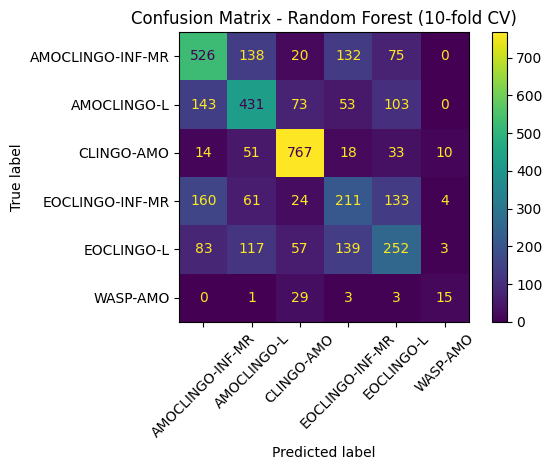

In [11]:
# Complete dataset with measp+amo/eo features
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings

warnings.filterwarnings('ignore')  


csv_path = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/measp_amoeo/training-dataset_amosum2.csv'


if csv_path == '':
    raise FileNotFoundError("No CSV file found in /kaggle/input")


df = pd.read_csv(csv_path)


df_clean = df[df['best_config'] != 'TIMEOUT']

X = df_clean.drop(columns=['domain', 'instance_name', 'best_config', 'min_time'])
y = df_clean['best_config']

print(f"Valid instances for training: {len(df_clean)}")


print("\nStarting 10-Fold Cross-Validation with Random Forest...")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

print("\nRESULTS 10-FOLD CV:")
print(f"Accuratezza Media: {scores.mean() * 100:.2f}%")
print(f"Deviazione Standard: +/- {scores.std() * 100:.2f}%")


print("\nAvarage feature importance on 10 fold...")

feature_importances = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf_fold = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    )

    rf_fold.fit(X_train, y_train)

    feature_importances.append(rf_fold.feature_importances_)

feature_importances = np.array(feature_importances)

mean_importances = feature_importances.mean(axis=0)
std_importances = feature_importances.std(axis=0)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'mean_importance': mean_importances,
    'std': std_importances
}).sort_values(by='mean_importance', ascending=False)

print("\n Top 10 of the most important feature:")
print(importance_df.head(10))


output_path = "/kaggle/working/feature_importance_cv.csv"
importance_df.to_csv(output_path, index=False)

print(f"\nFile saved in: {output_path}")

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = cross_val_predict(rf, X, y, cv=cv)

labels = sorted(y.unique())

# Confusion matrix
cm = confusion_matrix(y, y_pred, labels=labels)

print("\n Confusion Matrix:")
print(cm)

# Plot
plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format='d')
plt.title("Confusion Matrix - Random Forest (10-fold CV)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total instances (Train + Test Aij): 1049
Istanze valide totali dopo la pulizia: 1043
Classi mantenute: ['AMOCLINGO-INF-MR', 'CLINGO-AMO', 'EOCLINGO-INF-MR', 'EOCLINGO-L', 'AMOCLINGO-L']

--- DISTRIBUTION AFTER SPLIT ---
Training Instances (80%): 834
Testing Instances (20%): 209

Number of configurations in the NEW training set:
best_config
AMOCLINGO-INF-MR    371
CLINGO-AMO          154
EOCLINGO-INF-MR     142
EOCLINGO-L           87
AMOCLINGO-L          80

Number of configurations in the NEW testing set:
best_config
AMOCLINGO-INF-MR    93
CLINGO-AMO          39
EOCLINGO-INF-MR     36
EOCLINGO-L          21
AMOCLINGO-L         20
----------------------------------------

Starting 10-Fold Cross-Validation on Training Set...

 RESULTS 10-FOLD CV (on Training Set):
Avarage Accuracy: 66.32% (+/- 4.44%)
Macro F1-Score:    57.61% (+/- 5.65%)

📊 Classification Report 10-Fold CV (Training):
                  precision    recall  f1-score   support

AMOCLINGO-INF-MR       0.75      0.82      0

<Figure size 1000x800 with 0 Axes>

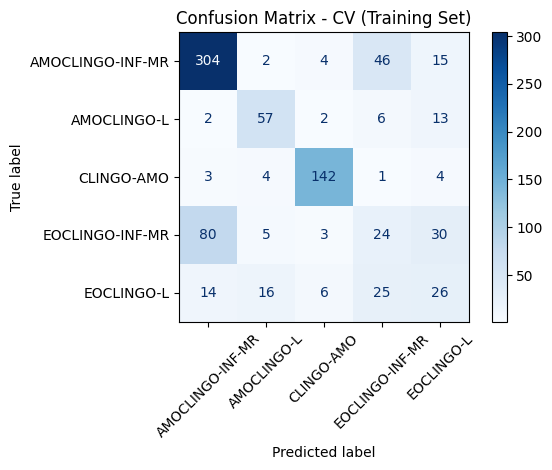


Top 10 of the most important features:
        feature  importance
16        bound    0.118407
23  minps_ratio    0.101612
22    mps_ratio    0.100542
24    tightness    0.094629
8            f1    0.046300
18       C2_sum    0.043832
17       C1_mps    0.041776
20         span    0.040138
1             a    0.038405
11       f_horn    0.037236

--- VALUTATION ON TESTING SET (20% HOLDOUT) ---

📊 Classification Report (Testing Set):
                  precision    recall  f1-score   support

AMOCLINGO-INF-MR       0.75      0.87      0.81        93
     AMOCLINGO-L       0.70      0.80      0.74        20
      CLINGO-AMO       0.90      0.92      0.91        39
 EOCLINGO-INF-MR       0.37      0.28      0.32        36
      EOCLINGO-L       0.55      0.29      0.38        21

        accuracy                           0.71       209
       macro avg       0.65      0.63      0.63       209
    weighted avg       0.69      0.71      0.69       209



<Figure size 1000x800 with 0 Axes>

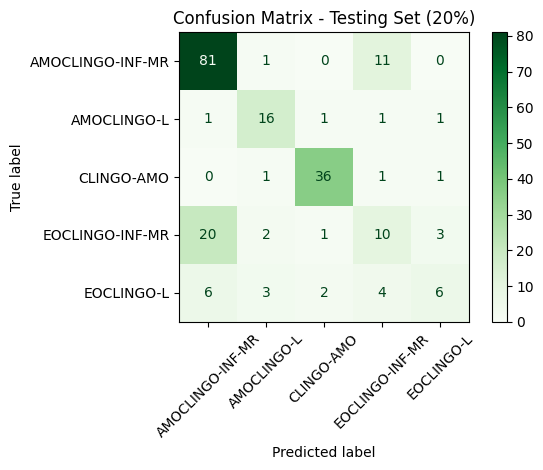

In [18]:
# preprocessed dataset usage, join with dataset aij paper (called testing_dataset), split 80/20
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

train_csv_path = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/measp_amoeo/training_dataset_amosum_prepro2.csv'
test_csv_path = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/measp_amoeo/testing_dataset_amosum.csv' #from aij

df_train = pd.read_csv(train_csv_path)
df_test = pd.read_csv(test_csv_path)

df_all = pd.concat([df_train, df_test], ignore_index=True)
print(f"Total instances (Train + Test Aij): {len(df_all)}")


df_clean = df_all[df_all['best_config'] != 'TIMEOUT']

# Removing classes with less than 10 global instances
MIN_INSTANCES = 10
class_counts = df_clean['best_config'].value_counts()
valid_classes = class_counts[class_counts >= MIN_INSTANCES].index
df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]

X = df_clean.drop(columns=['domain', 'instance_name', 'best_config', 'min_time', 'performance_ratio'], errors='ignore')
y = df_clean['best_config']

print(f"Istanze valide totali dopo la pulizia: {len(df_clean)}")
print(f"Classi mantenute: {list(valid_classes)}\n")


# usage of stratify=y for mantaining the proportion of classes for both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("--- DISTRIBUTION AFTER SPLIT ---")
print(f"Training Instances (80%): {len(X_train)}")
print(f"Testing Instances (20%): {len(X_test)}")
print("\nNumber of configurations in the NEW training set:")
print(y_train.value_counts().to_string())
print("\nNumber of configurations in the NEW testing set:")
print(y_test.value_counts().to_string())
print("-" * 40)


print("\nStarting 10-Fold Cross-Validation on Training Set...")

rf = RandomForestClassifier(
    n_estimators=200,          
    max_depth=15,              
    min_samples_split=5,       
    random_state=42,
    class_weight='balanced',
    n_jobs=-1                  
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1_macro')

print("\n RESULTS 10-FOLD CV (on Training Set):")
print(f"Avarage Accuracy: {acc_scores.mean() * 100:.2f}% (+/- {acc_scores.std() * 100:.2f}%)")
print(f"Macro F1-Score:    {f1_scores.mean() * 100:.2f}% (+/- {f1_scores.std() * 100:.2f}%)")


y_pred_cv = cross_val_predict(rf, X_train, y_train, cv=cv)
labels = sorted(y_train.unique())

print("\n📊 Classification Report 10-Fold CV (Training):")
print(classification_report(y_train, y_pred_cv))

cm_cv = confusion_matrix(y_train, y_pred_cv, labels=labels)

plt.figure(figsize=(10,8))
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=labels)
disp_cv.plot(cmap='Blues', values_format='d', xticks_rotation=45)
plt.title("Confusion Matrix - CV (Training Set)")
plt.tight_layout()
plt.show()


rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 10 of the most important features:")
print(importance_df.head(10))


print("\n--- VALUTATION ON TESTING SET (20% HOLDOUT) ---")

y_pred_test = rf.predict(X_test)

print("\n📊 Classification Report (Testing Set):")
print(classification_report(y_test, y_pred_test, labels=labels, zero_division=0))

cm_test = confusion_matrix(y_test, y_pred_test, labels=labels)

plt.figure(figsize=(10,8))
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
disp_test.plot(cmap='Greens', values_format='d', xticks_rotation=45)
plt.title("Confusion Matrix - Testing Set (20%)")
plt.tight_layout()
plt.show()

Total instances (original train + test): 1049
Total valid instances after cleaning: 1043
Number of selected features: 15
Retained classes: ['AMOCLINGO-INF-MR', 'CLINGO-AMO', 'EOCLINGO-INF-MR', 'EOCLINGO-L', 'AMOCLINGO-L']

--- DISTRIBUTION AFTER SPLIT ---
Training instances (80%): 834
Testing instances (20%): 209

Starting 10-fold cross-validation with SMOTE on the training set...

10-fold CV results (with SMOTE):
Mean accuracy: 60.93% (+/- 4.67%)
Macro F1-score: 56.47% (+/- 3.57%)

Classification report (10-fold CV on training with SMOTE):
                  precision    recall  f1-score   support

AMOCLINGO-INF-MR       0.75      0.67      0.71       371
     AMOCLINGO-L       0.65      0.74      0.69        80
      CLINGO-AMO       0.87      0.90      0.88       154
 EOCLINGO-INF-MR       0.22      0.23      0.23       142
      EOCLINGO-L       0.29      0.36      0.32        87

        accuracy                           0.61       834
       macro avg       0.56      0.58      0.

<Figure size 1000x800 with 0 Axes>

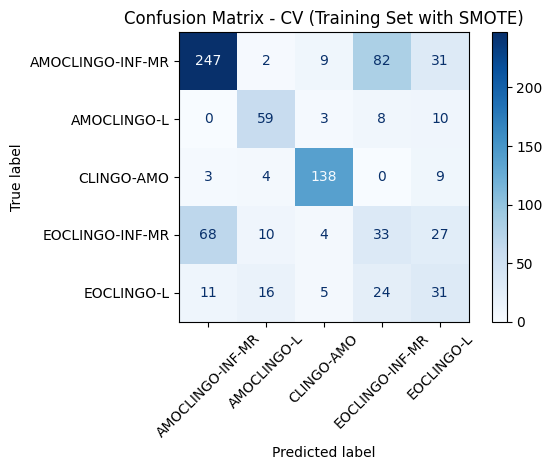


Applying SMOTE to the full training set (80%) for final model...
Training instances before SMOTE: 834
Training instances after SMOTE: 1495

Top 10 most important features (global model on SMOTE data):
        feature  importance
4         bound    0.114042
3     mps_ratio    0.113162
0   minps_ratio    0.094053
5     tightness    0.081690
2      C3_minps    0.070662
8        C2_sum    0.067440
1          span    0.066438
7        C1_mps    0.063276
11           f1    0.060373
12            r    0.054567

--- FINAL EVALUATION ON HOLDOUT TEST SET (20%) ---

Classification report (test set):
                  precision    recall  f1-score   support

AMOCLINGO-INF-MR       0.77      0.75      0.76        93
     AMOCLINGO-L       0.68      0.75      0.71        20
      CLINGO-AMO       0.89      0.82      0.85        39
 EOCLINGO-INF-MR       0.33      0.36      0.34        36
      EOCLINGO-L       0.35      0.33      0.34        21

        accuracy                           0.66      

<Figure size 1000x800 with 0 Axes>

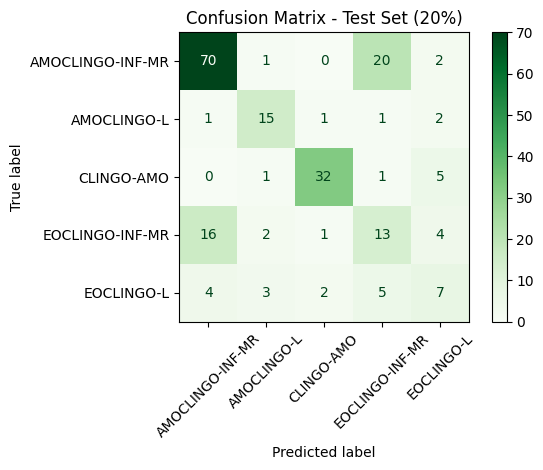

In [17]:
# Minority class elimination, feature selection, dataset merge, 80/20 split, and SMOTEK in CV
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')

train_csv_path = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/measp_amoeo/training_dataset_amosum_prepro2.csv'
test_csv_path = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/measp_amoeo/testing_dataset_amosum.csv'

df_train = pd.read_csv(train_csv_path)
df_test = pd.read_csv(test_csv_path)

df_all = pd.concat([df_train, df_test], ignore_index=True)
print(f"Total instances (original train + test): {len(df_all)}")

df_clean = df_all[df_all['best_config'] != 'TIMEOUT'].copy()

MIN_INSTANCES = 10
class_counts = df_clean['best_config'].value_counts()
valid_classes = class_counts[class_counts >= MIN_INSTANCES].index
df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]

crucial_features = [
    'minps_ratio', 'span', 'max_min_diff', 'C3_minps', 
    'mps_ratio', 'bound', 'tightness', 'rho', 'C1_mps', 'C2_sum',
    'f_horn', 'a', 'f1', 'r', 'n_facts', 'f2' 
]

features_to_use = [f for f in crucial_features if f in df_clean.columns]

X = df_clean[features_to_use]
y = df_clean['best_config']

print(f"Total valid instances after cleaning: {len(df_clean)}")
print(f"Number of selected features: {len(X.columns)}")
print(f"Retained classes: {list(valid_classes)}\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("--- DISTRIBUTION AFTER SPLIT ---")
print(f"Training instances (80%): {len(X_train)}")
print(f"Testing instances (20%): {len(X_test)}\n")

print("Starting 10-fold cross-validation with SMOTE on the training set...")

rf = RandomForestClassifier(
    n_estimators=200,          
    max_depth=15,              
    min_samples_split=5,       
    random_state=42,
    n_jobs=-1                  
)

smote_tomek = SMOTETomek(random_state=42)

pipeline = ImbPipeline(steps=[
    ('smotetomek', smote_tomek),
    ('rf', rf)
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro')

print("\n10-fold CV results (with SMOTE):")
print(f"Mean accuracy: {acc_scores.mean() * 100:.2f}% (+/- {acc_scores.std() * 100:.2f}%)")
print(f"Macro F1-score: {f1_scores.mean() * 100:.2f}% (+/- {f1_scores.std() * 100:.2f}%)")

y_pred_cv = cross_val_predict(pipeline, X_train, y_train, cv=cv)
labels = sorted(y_train.unique())

print("\nClassification report (10-fold CV on training with SMOTE):")
print(classification_report(y_train, y_pred_cv))

cm_cv = confusion_matrix(y_train, y_pred_cv, labels=labels)

plt.figure(figsize=(10,8))
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=labels)
disp_cv.plot(cmap='Blues', values_format='d', xticks_rotation=45)
plt.title("Confusion Matrix - CV (Training Set with SMOTE)")
plt.tight_layout()
plt.show()

print("\nApplying SMOTE to the full training set (80%) for final model...")

X_train_smote, y_train_smote = smote_tomek.fit_resample(X_train, y_train)

print(f"Training instances before SMOTE: {len(y_train)}")
print(f"Training instances after SMOTE: {len(y_train_smote)}")

rf.fit(X_train_smote, y_train_smote) 

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 10 most important features (global model on SMOTE data):")
print(importance_df.head(10))

print("\n--- FINAL EVALUATION ON HOLDOUT TEST SET (20%) ---")

y_pred_test = rf.predict(X_test)

print("\nClassification report (test set):")
print(classification_report(y_test, y_pred_test, labels=labels, zero_division=0))

cm_test = confusion_matrix(y_test, y_pred_test, labels=labels)

plt.figure(figsize=(10,8))
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
disp_test.plot(cmap='Greens', values_format='d', xticks_rotation=45)
plt.title("Confusion Matrix - Test Set (20%)")
plt.tight_layout()
plt.show()


STARTING SPECIALIST PIPELINE: AMO SELECTOR (XGBOOST)
Total loaded instances (original train + test): 1587
Valid instances after timeout/rare filtering: 1580

--- DISTRIBUTION AFTER SPLIT ---
Training instances (80%): 1264 | Testing instances (20%): 316
--- 10-FOLD CROSS-VALIDATION (ON TRAINING SET) ---
Mean accuracy: 87.81% (+/- 3.02%)
Macro F1-score: 87.67% (+/- 2.65%)

--- CLASSIFICATION REPORT (TEST SET) ---
                  precision    recall  f1-score   support

AMOCLINGO-INF-MR       0.95      0.88      0.91       158
     AMOCLINGO-L       0.84      0.91      0.87       116
      CLINGO-AMO       0.84      0.88      0.86        42

        accuracy                           0.89       316
       macro avg       0.88      0.89      0.88       316
    weighted avg       0.89      0.89      0.89       316



<Figure size 800x600 with 0 Axes>

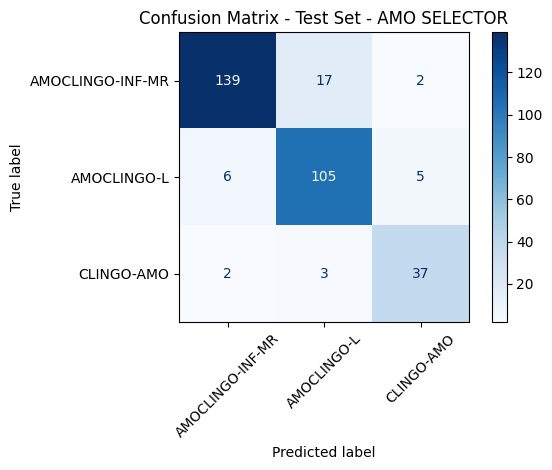

AMO model and test set saved successfully!

STARTING SPECIALIST PIPELINE: EO SELECTOR (XGBOOST)
Total loaded instances (original train + test): 1194
Valid instances after timeout/rare filtering: 1176

--- DISTRIBUTION AFTER SPLIT ---
Training instances (80%): 940 | Testing instances (20%): 236
--- 10-FOLD CROSS-VALIDATION (ON TRAINING SET) ---
Mean accuracy: 75.11% (+/- 3.72%)
Macro F1-score: 76.79% (+/- 3.55%)

--- CLASSIFICATION REPORT (TEST SET) ---
                 precision    recall  f1-score   support

     CLINGO-AMO       0.95      0.91      0.93        46
EOCLINGO-INF-MR       0.77      0.82      0.79       111
     EOCLINGO-L       0.72      0.67      0.69        79

       accuracy                           0.79       236
      macro avg       0.81      0.80      0.81       236
   weighted avg       0.79      0.79      0.79       236



<Figure size 800x600 with 0 Axes>

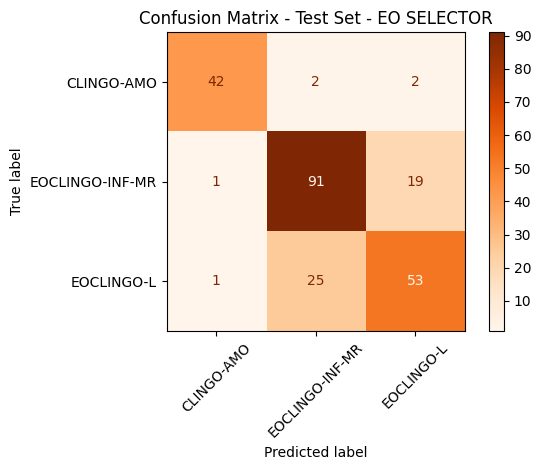

EO model and test set saved successfully!


In [22]:
# new pipeline: amo and eo selectors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
import joblib

warnings.filterwarnings('ignore')

path_amo_train = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/training_dataset_amo.csv'
path_amo_test  = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/testing_dataset_amo.csv'

path_eo_train  = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/training_dataset_eo.csv'
path_eo_test   = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/testing_dataset_eo.csv'

common_features = [
    'bound', 'C2_sum', 'tightness', 
    'f_horn', 'a', 'f1', 'r', 'n_facts', 'f2'
]

features_amo = common_features + ['C1_mps', 'rho', 'mps_ratio']
features_eo = common_features + ['C3_minps', 'span_ratio', 'minps_ratio', 'span_log']

def train_and_evaluate_specialist(train_path, test_path, features, model_name, cmap_color, enc):
    print(f"\n{'='*60}")
    print(f"STARTING SPECIALIST PIPELINE: {model_name} (XGBOOST)")
    print(f"{'='*60}")
    
    df_train_orig = pd.read_csv(train_path)
    df_test_orig = pd.read_csv(test_path)
    df_all = pd.concat([df_train_orig, df_test_orig], ignore_index=True)
    print(f"Total loaded instances (original train + test): {len(df_all)}")
    
    df_clean = df_all[df_all['best_config'] != 'TIMEOUT'].copy()
    
    MIN_INSTANCES = 50
    class_counts = df_clean['best_config'].value_counts()
    valid_classes = class_counts[class_counts >= MIN_INSTANCES].index
    df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]
    print(f"Valid instances after timeout/rare filtering: {len(df_clean)}")

    if 'span' in df_clean.columns:
        df_clean['span_ratio'] = np.where(df_clean['bound'] > 0, df_clean['span'] / df_clean['bound'], 0)
        df_clean['span_log'] = np.log1p(df_clean['span'])
    
    valid_features = [f for f in features if f in df_clean.columns]
    X = df_clean[valid_features]
    y_raw = df_clean['best_config']
    
    nomi_istanze = df_clean['instance_name'] if 'instance_name' in df_clean.columns else df_clean.index
    
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    
    X_train, X_test, y_train, y_test, istanze_train, istanze_test = train_test_split(
        X, y, nomi_istanze, test_size=0.20, stratify=y, random_state=42
    )
    
    print("\n--- DISTRIBUTION AFTER SPLIT ---")
    print(f"Training instances (80%): {len(X_train)} | Testing instances (20%): {len(X_test)}")
    
    if enc == 'amo':
        xgb_model = XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            random_state=42, n_jobs=-1, eval_metric='mlogloss'
        )
        sample_weights_train = compute_sample_weight('balanced', y_train)

    if enc == 'eo':
        xgb_model = XGBClassifier(
            n_estimators=500, max_depth=8, learning_rate=0.05,
            random_state=42, n_jobs=-1, eval_metric='mlogloss'
        )
        sample_weights_train = compute_sample_weight('balanced', y_train)
        
        if 'EOCLINGO-L' in le.classes_:
            l_idx = le.transform(['EOCLINGO-L'])[0]
            sample_weights_train[y_train == l_idx] *= 1.8
    
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    acc_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='f1_macro')
    
    print("--- 10-FOLD CROSS-VALIDATION (ON TRAINING SET) ---")
    print(f"Mean accuracy: {acc_scores.mean() * 100:.2f}% (+/- {acc_scores.std() * 100:.2f}%)")
    print(f"Macro F1-score: {f1_scores.mean() * 100:.2f}% (+/- {f1_scores.std() * 100:.2f}%)\n")
    
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train)
    
    y_pred_test = xgb_model.predict(X_test)
    y_test_labels = le.inverse_transform(y_test)
    y_pred_labels = le.inverse_transform(y_pred_test)
    labels_string = list(le.classes_)
    
    print("--- CLASSIFICATION REPORT (TEST SET) ---")
    print(classification_report(y_test_labels, y_pred_labels, labels=labels_string, zero_division=0))
    
    cm_test = confusion_matrix(y_test_labels, y_pred_labels, labels=labels_string)
    plt.figure(figsize=(8,6))
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels_string)
    disp_test.plot(cmap=cmap_color, values_format='d', xticks_rotation=45)
    plt.title(f"Confusion Matrix - Test Set - {model_name}")
    plt.tight_layout()
    plt.show()

    return xgb_model, le, X_test, y_test_labels, istanze_test

modello_amo, le_amo, X_test_amo, y_test_labels_amo, istanze_test_amo = train_and_evaluate_specialist(
    train_path=path_amo_train, 
    test_path=path_amo_test, 
    features=features_amo, 
    model_name="AMO SELECTOR", 
    cmap_color='Blues',
    enc='amo'
)

joblib.dump({'model': modello_amo, 'label_encoder': le_amo}, 'model_AMO_xgboost.joblib')

df_test_amo = X_test_amo.copy()
df_test_amo.insert(0, 'instance_name', istanze_test_amo.values)
df_test_amo['best_config_TRUE'] = y_test_labels_amo 
df_test_amo.to_csv('test_set_AMO_20perc.csv', index=False)
print("AMO model and test set saved successfully!")

modello_eo, le_eo, X_test_eo, y_test_labels_eo, istanze_test_eo = train_and_evaluate_specialist(
    train_path=path_eo_train, 
    test_path=path_eo_test, 
    features=features_eo, 
    model_name="EO SELECTOR", 
    cmap_color='Oranges',
    enc='eo'
)

joblib.dump({'model': modello_eo, 'label_encoder': le_eo}, 'model_EO_xgboost.joblib')

df_test_eo = X_test_eo.copy()
df_test_eo.insert(0, 'instance_name', istanze_test_eo.values)
df_test_eo['best_config_TRUE'] = y_test_labels_eo 
df_test_eo.to_csv('test_set_EO_20perc.csv', index=False)
print("EO model and test set saved successfully!")

In [23]:
import pandas as pd

def compare_distributions(train_path, test_path, dataset_name):
    print(f"\n{'='*75}")
    print(f"DISTRIBUTION AND WIN ANALYSIS - DATASET {dataset_name.upper()}")
    print(f"{'='*75}")
    
    df_train_orig = pd.read_csv(train_path)
    df_test_orig = pd.read_csv(test_path)
    df_all = pd.concat([df_train_orig, df_test_orig], ignore_index=True)
    
    print("\nBEFORE PREPROCESSING (Original Train + Test)")
    print("-" * 55)
    dist_before = pd.DataFrame({
        'Count': df_all['best_config'].value_counts(dropna=False),
        'Percentage': (df_all['best_config'].value_counts(normalize=True, dropna=False) * 100).round(2).astype(str) + '%'
    })
    print(dist_before.to_string())
    print(f"Total initial instances: {len(df_all)}\n")
    
    df_solved = df_all[df_all['best_config'] != 'TIMEOUT'].copy()
    
    if 'domain' in df_solved.columns:
        print("WINS PER BENCHMARK (Timeouts excluded)")
        print("-" * 75)
        tabella_vittorie = pd.crosstab(df_solved['domain'], df_solved['best_config'], margins=True, margins_name="Total")
        print(tabella_vittorie.to_string())
        print("\n")
    else:
        print("Column 'domain' not found. Cannot generate benchmark table.\n")
    
    df_clean = df_solved.copy()
    
    MIN_INSTANCES = 50
    class_counts = df_clean['best_config'].value_counts()
    valid_classes = class_counts[class_counts >= MIN_INSTANCES].index
    df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]
    
    print("AFTER PREPROCESSING (No TIMEOUT, Classes >= 50)")
    print("-" * 55)
    dist_after = pd.DataFrame({
        'Count': df_clean['best_config'].value_counts(),
        'Percentage': (df_clean['best_config'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
    })
    print(dist_after.to_string())
    print(f"Total cleaned instances: {len(df_clean)}\n")
    
    scartate = len(df_all) - len(df_clean)
    perc_scarto = (scartate / len(df_all)) * 100
    print(f"Cleaning summary: removed {scartate} instances ({perc_scarto:.2f}% of the original dataset).")

path_amo_train = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/training_dataset_amo.csv'
path_amo_test  = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/testing_dataset_amo.csv'
path_eo_train  = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/training_dataset_eo.csv'
path_eo_test   = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/testing_dataset_eo.csv'

compare_distributions(path_amo_train, path_amo_test, "AMO")
compare_distributions(path_eo_train, path_eo_test, "EO")


DISTRIBUTION AND WIN ANALYSIS - DATASET AMO

BEFORE PREPROCESSING (Original Train + Test)
-------------------------------------------------------
                  Count Percentage
best_config                       
AMOCLINGO-INF-MR    791     49.84%
AMOCLINGO-L         578     36.42%
CLINGO-AMO          211      13.3%
WASP-AMO              7      0.44%
Total initial instances: 1587

WINS PER BENCHMARK (Timeouts excluded)
---------------------------------------------------------------------------
best_config      AMOCLINGO-INF-MR  AMOCLINGO-L  CLINGO-AMO  WASP-AMO  Total
domain                                                                     
GraphColouring                 13          421          41         6    481
GroupAssignment               752           89          90         1    932
Knapsack                       26           68          80         0    174
Total                         791          578         211         7   1587


AFTER PREPROCESSING (No TIMEOUT, Classe

In [27]:
!pip install lightgbm
!pip install foldrpp 

  Preparing metadata (setup.py) ... done
  Created wheel for foldrpp: filename=foldrpp-0.0.2-py3-none-any.whl size=10810 sha256=084e812e68a968c38e872d59a9b90ac658d74bd8887c2d5be29b860e3f004540
  Stored in directory: /root/.cache/pip/wheels/cd/8d/00/91971183634fbc35f527234debd6637fd4bef552d48fd95fd2
Successfully built foldrpp


In [ ]:
# cascade pipeline with decision tree at level 1 and xgboost at level 23

Training Level 1: Triage (Decision Tree)...
Training Level 2: Oracle (XGBoost)...

CASCADED ARCHITECTURE RESULTS (Confidence threshold: 75.0%)
Total test instances evaluated: 316
Handled by Decision Tree (Triage): 262 (82.9%)
Handled by XGBoost (Oracle):       54 (17.1%)

--- CLASSIFICATION REPORT ---
                  precision    recall  f1-score   support

AMOCLINGO-INF-MR       0.94      0.84      0.88       158
     AMOCLINGO-L       0.81      0.92      0.86       116
      CLINGO-AMO       0.67      0.69      0.68        42

        accuracy                           0.85       316
       macro avg       0.81      0.82      0.81       316
    weighted avg       0.86      0.85      0.85       316

Overall accuracy of the cascaded system: 84.81%


<Figure size 800x600 with 0 Axes>

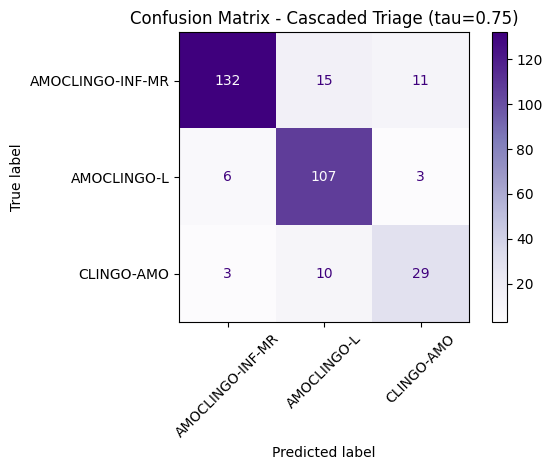


Saving cascaded architecture...
Model successfully saved at: /kaggle/working/cascaded_model_AMO.joblib


In [28]:
#amo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
import joblib

warnings.filterwarnings('ignore')

path_amo_train = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/training_dataset_amo.csv'
path_amo_test  = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/testing_dataset_amo.csv'

df_train = pd.read_csv(path_amo_train)
df_test = pd.read_csv(path_amo_test)
df_all = pd.concat([df_train, df_test], ignore_index=True)

df_clean = df_all[df_all['best_config'] != 'TIMEOUT'].copy()
MIN_INSTANCES = 50
valid_classes = df_clean['best_config'].value_counts()[df_clean['best_config'].value_counts() >= MIN_INSTANCES].index
df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]

features_amo = [
    'bound', 'C2_sum', 'tightness', 'f_horn', 'a', 'f1', 'r', 'n_facts', 'f2', 
    'C1_mps', 'rho', 'mps_ratio'
]

valid_features = [f for f in features_amo if f in df_clean.columns]
X = df_clean[valid_features]
y_raw = df_clean['best_config']

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("Training Level 1: Triage (Decision Tree)...")
dt_triage = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dt_triage.fit(X_train, y_train)

print("Training Level 2: Oracle (XGBoost)...")
sample_weights = compute_sample_weight('balanced', y_train)
if 'AMOOCLINGO-L' in le.classes_:
    l_idx = le.transform(['EOCLINGO-L'])[0]
    sample_weights[y_train == l_idx] *= 1.8

xgb_oracle = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    random_state=42, n_jobs=-1, eval_metric='mlogloss'
)
xgb_oracle.fit(X_train, y_train, sample_weight=sample_weights)

def predict_cascata(X_data, model_triage, model_oracolo, soglia_confidenza=0.75):
    predizioni_finali = []
    contatore_albero = 0
    contatore_xgboost = 0
    
    probabilita_albero = model_triage.predict_proba(X_data)
    confidenza_massima = np.max(probabilita_albero, axis=1)
    
    scelte_albero = model_triage.predict(X_data)
    scelte_xgboost = model_oracolo.predict(X_data)
    
    for i in range(len(X_data)):
        if confidenza_massima[i] >= soglia_confidenza:
            predizioni_finali.append(scelte_albero[i])
            contatore_albero += 1
        else:
            predizioni_finali.append(scelte_xgboost[i])
            contatore_xgboost += 1
            
    return np.array(predizioni_finali), contatore_albero, contatore_xgboost

SOGLIA = 0.75

y_pred_cascata, uso_albero, uso_xgb = predict_cascata(
    X_test, dt_triage, xgb_oracle, soglia_confidenza=SOGLIA
)

y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred_cascata)
labels_string = list(le.classes_)

print("\n" + "="*60)
print(f"CASCADED ARCHITECTURE RESULTS (Confidence threshold: {SOGLIA*100}%)")
print("="*60)
print(f"Total test instances evaluated: {len(X_test)}")
print(f"Handled by Decision Tree (Triage): {uso_albero} ({(uso_albero/len(X_test))*100:.1f}%)")
print(f"Handled by XGBoost (Oracle):       {uso_xgb} ({(uso_xgb/len(X_test))*100:.1f}%)")

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test_labels, y_pred_labels, labels=labels_string, zero_division=0))

acc_cascata = accuracy_score(y_test, y_pred_cascata)
print(f"Overall accuracy of the cascaded system: {acc_cascata*100:.2f}%")

cm_test = confusion_matrix(y_test_labels, y_pred_labels, labels=labels_string)
plt.figure(figsize=(8,6))
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels_string)
disp_test.plot(cmap='Purples', values_format='d', xticks_rotation=45)
plt.title(f"Confusion Matrix - Cascaded Triage (tau={SOGLIA})")
plt.tight_layout()
plt.show()

print("\nSaving cascaded architecture...")

ecosistema_cascata = {
    'modello_triage': dt_triage,
    'modello_oracolo': xgb_oracle,
    'label_encoder': le,
    'soglia_confidenza': SOGLIA,
    'feature_names': valid_features,
    'tipo_modello': 'cascata'
}

percorso_salvataggio = '/kaggle/working/cascaded_model_AMO.joblib'

joblib.dump(ecosistema_cascata, percorso_salvataggio)
print(f"Model successfully saved at: {percorso_salvataggio}")

Training Level 1: Triage (Decision Tree)...
Training Level 2: Oracle (XGBoost)...

CASCADED ARCHITECTURE RESULTS (Confidence threshold: 75.0%)
Total test instances evaluated: 236
Handled by Decision Tree (Triage): 91 (38.6%)
Handled by XGBoost (Oracle):       145 (61.4%)

--- CLASSIFICATION REPORT ---
                 precision    recall  f1-score   support

     CLINGO-AMO       0.95      0.91      0.93        46
EOCLINGO-INF-MR       0.77      0.83      0.80       111
     EOCLINGO-L       0.72      0.66      0.69        79

       accuracy                           0.79       236
      macro avg       0.81      0.80      0.81       236
   weighted avg       0.79      0.79      0.79       236

Overall accuracy of the cascaded system: 78.81%


<Figure size 800x600 with 0 Axes>

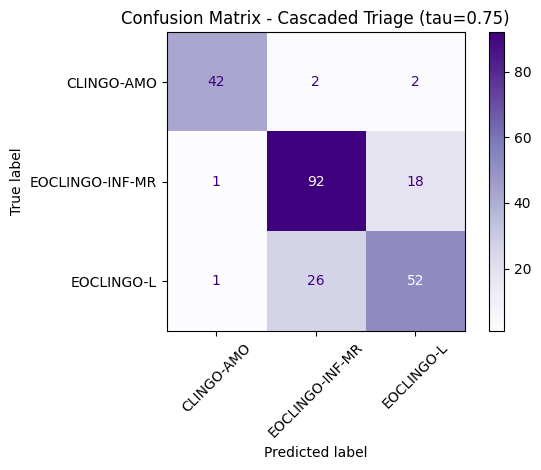


Saving cascaded architecture...
Model successfully saved at: /kaggle/working/cascaded_model_EO.joblib


In [29]:
#eo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
import joblib

warnings.filterwarnings('ignore')

path_eo_train = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/training_dataset_eo.csv'
path_eo_test  = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/testing_dataset_eo.csv'

df_train = pd.read_csv(path_eo_train)
df_test = pd.read_csv(path_eo_test)
df_all = pd.concat([df_train, df_test], ignore_index=True)

df_clean = df_all[df_all['best_config'] != 'TIMEOUT'].copy()
MIN_INSTANCES = 50
valid_classes = df_clean['best_config'].value_counts()[df_clean['best_config'].value_counts() >= MIN_INSTANCES].index
df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]

if 'span' in df_clean.columns:
    df_clean['span_ratio'] = np.where(df_clean['bound'] > 0, df_clean['span'] / df_clean['bound'], 0)
    df_clean['span_log'] = np.log1p(df_clean['span'])

features_eo = [
    'bound', 'C2_sum', 'tightness', 'f_horn', 'a', 'f1', 'r', 'n_facts', 'f2', 
    'C3_minps', 'span_ratio', 'minps_ratio', 'span_log'
]

valid_features = [f for f in features_eo if f in df_clean.columns]
X = df_clean[valid_features]
y_raw = df_clean['best_config']

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("Training Level 1: Triage (Decision Tree)...")
dt_triage = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dt_triage.fit(X_train, y_train)

print("Training Level 2: Oracle (XGBoost)...")
sample_weights = compute_sample_weight('balanced', y_train)
if 'EOCLINGO-L' in le.classes_:
    l_idx = le.transform(['EOCLINGO-L'])[0]
    sample_weights[y_train == l_idx] *= 1.8

xgb_oracle = XGBClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    random_state=42, n_jobs=-1, eval_metric='mlogloss'
)
xgb_oracle.fit(X_train, y_train, sample_weight=sample_weights)

def predict_cascata(X_data, model_triage, model_oracolo, soglia_confidenza=0.75):
    predizioni_finali = []
    contatore_albero = 0
    contatore_xgboost = 0
    
    probabilita_albero = model_triage.predict_proba(X_data)
    confidenza_massima = np.max(probabilita_albero, axis=1)
    
    scelte_albero = model_triage.predict(X_data)
    scelte_xgboost = model_oracolo.predict(X_data)
    
    for i in range(len(X_data)):
        if confidenza_massima[i] >= soglia_confidenza:
            predizioni_finali.append(scelte_albero[i])
            contatore_albero += 1
        else:
            predizioni_finali.append(scelte_xgboost[i])
            contatore_xgboost += 1
            
    return np.array(predizioni_finali), contatore_albero, contatore_xgboost

SOGLIA = 0.75

y_pred_cascata, uso_albero, uso_xgb = predict_cascata(
    X_test, dt_triage, xgb_oracle, soglia_confidenza=SOGLIA
)

y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred_cascata)
labels_string = list(le.classes_)

print("\n" + "="*60)
print(f"CASCADED ARCHITECTURE RESULTS (Confidence threshold: {SOGLIA*100}%)")
print("="*60)
print(f"Total test instances evaluated: {len(X_test)}")
print(f"Handled by Decision Tree (Triage): {uso_albero} ({(uso_albero/len(X_test))*100:.1f}%)")
print(f"Handled by XGBoost (Oracle):       {uso_xgb} ({(uso_xgb/len(X_test))*100:.1f}%)")

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test_labels, y_pred_labels, labels=labels_string, zero_division=0))

acc_cascata = accuracy_score(y_test, y_pred_cascata)
print(f"Overall accuracy of the cascaded system: {acc_cascata*100:.2f}%")

cm_test = confusion_matrix(y_test_labels, y_pred_labels, labels=labels_string)
plt.figure(figsize=(8,6))
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels_string)
disp_test.plot(cmap='Purples', values_format='d', xticks_rotation=45)
plt.title(f"Confusion Matrix - Cascaded Triage (tau={SOGLIA})")
plt.tight_layout()
plt.show()

print("\nSaving cascaded architecture...")

ecosistema_cascata = {
    'modello_triage': dt_triage,
    'modello_oracolo': xgb_oracle,
    'label_encoder': le,
    'soglia_confidenza': SOGLIA,
    'feature_names': valid_features,
    'tipo_modello': 'cascata'
}

percorso_salvataggio = '/kaggle/working/cascaded_model_EO.joblib'

joblib.dump(ecosistema_cascata, percorso_salvataggio)
print(f"Model successfully saved at: {percorso_salvataggio}")

In [ ]:
# goal: find the best combination of depth and confidence threeshold

Training Oracle (XGBoost)...

Searching for optimal configuration...


Top configurations:
    depth  threshold  accuracy  tree_usage
33      7       0.65  0.895570    0.895570
32      7       0.60  0.886076    0.920886
35      7       0.75  0.882911    0.819620
34      7       0.70  0.882911    0.844937
22      5       0.90  0.882911    0.670886
23      5       0.95  0.882911    0.661392
30      6       0.90  0.882911    0.727848
31      6       0.95  0.882911    0.642405
36      7       0.80  0.882911    0.800633
37      7       0.85  0.882911    0.778481


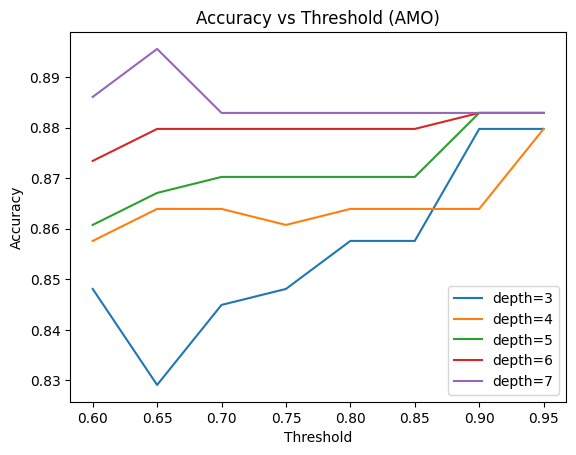


Best configuration:
Depth: 7
Threshold: 0.65
Accuracy: 0.8956

Final classification report:
                  precision    recall  f1-score   support

AMOCLINGO-INF-MR       0.94      0.89      0.91       158
     AMOCLINGO-L       0.87      0.91      0.89       116
      CLINGO-AMO       0.83      0.90      0.86        42

        accuracy                           0.90       316
       macro avg       0.88      0.90      0.89       316
    weighted avg       0.90      0.90      0.90       316


Final accuracy: 89.56%
Decision Tree usage: 89.6%
XGBoost usage: 10.4%

Model saved with optimal configuration!


In [30]:
#amo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings
import joblib

warnings.filterwarnings('ignore')

path_amo_train = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/training_dataset_amo.csv'
path_amo_test  = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/testing_dataset_amo.csv'

df_train = pd.read_csv(path_amo_train)
df_test = pd.read_csv(path_amo_test)
df_all = pd.concat([df_train, df_test], ignore_index=True)

df_clean = df_all[df_all['best_config'] != 'TIMEOUT'].copy()

MIN_INSTANCES = 50
valid_classes = df_clean['best_config'].value_counts()
valid_classes = valid_classes[valid_classes >= MIN_INSTANCES].index
df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]

features_amo = [
    'bound', 'C2_sum', 'tightness', 'f_horn', 'a', 'f1', 'r', 'n_facts', 'f2', 
    'C1_mps', 'rho', 'mps_ratio'
]

valid_features = [f for f in features_amo if f in df_clean.columns]

X = df_clean[valid_features]
y_raw = df_clean['best_config']

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Training Oracle (XGBoost)...")

sample_weights = compute_sample_weight('balanced', y_train)

if 'AMOCLINGO-L' in le.classes_:
    l_idx = le.transform(['AMOCLINGO-L'])[0]
    sample_weights[y_train == l_idx] *= 1.8

xgb_oracle = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_oracle.fit(X_train, y_train, sample_weight=sample_weights)

def predict_cascata(X_data, model_triage, model_oracolo, soglia_confidenza=0.75):
    predizioni_finali = []
    contatore_albero = 0
    contatore_oracolo = 0
    
    probabilita_albero = model_triage.predict_proba(X_data)
    confidenza_massima = np.max(probabilita_albero, axis=1)
    
    scelte_albero = model_triage.predict(X_data)
    scelte_oracolo = model_oracolo.predict(X_data)
    
    for i in range(len(X_data)):
        if confidenza_massima[i] >= soglia_confidenza:
            predizioni_finali.append(scelte_albero[i])
            contatore_albero += 1
        else:
            predizioni_finali.append(scelte_oracolo[i])
            contatore_oracolo += 1
            
    return np.array(predizioni_finali), contatore_albero, contatore_oracolo

depth_values = [3, 4, 5, 6, 7]
soglie = np.arange(0.60, 0.96, 0.05)

risultati = []

print("\nSearching for optimal configuration...\n")

for depth in depth_values:
    
    dt_triage = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    )
    dt_triage.fit(X_train, y_train)
    
    for soglia in soglie:
        
        y_pred, uso_albero, uso_oracolo = predict_cascata(
            X_test, dt_triage, xgb_oracle, soglia_confidenza=soglia
        )
        
        acc = accuracy_score(y_test, y_pred)
        
        risultati.append({
            'depth': depth,
            'threshold': soglia,
            'accuracy': acc,
            'tree_usage': uso_albero / len(X_test)
        })

df_risultati = pd.DataFrame(risultati)
df_sorted = df_risultati.sort_values(by='accuracy', ascending=False)

print("\nTop configurations:")
print(df_sorted.head(10))

plt.figure()

for depth in depth_values:
    subset = df_risultati[df_risultati['depth'] == depth]
    plt.plot(subset['threshold'], subset['accuracy'], label=f'depth={depth}')

plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Threshold (AMO)")
plt.legend()
plt.show()

best = df_sorted.iloc[0]

BEST_DEPTH = int(best['depth'])
BEST_THRESHOLD = float(best['threshold'])

print("\nBest configuration:")
print(f"Depth: {BEST_DEPTH}")
print(f"Threshold: {BEST_THRESHOLD}")
print(f"Accuracy: {best['accuracy']:.4f}")

dt_final = DecisionTreeClassifier(
    max_depth=BEST_DEPTH,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

dt_final.fit(X_train, y_train)

y_pred_final, uso_albero, uso_oracolo = predict_cascata(
    X_test, dt_final, xgb_oracle, soglia_confidenza=BEST_THRESHOLD
)

y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred_final)

print("\nFinal classification report:")
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))

acc_final = accuracy_score(y_test, y_pred_final)

print(f"\nFinal accuracy: {acc_final*100:.2f}%")
print(f"Decision Tree usage: {(uso_albero/len(X_test))*100:.1f}%")
print(f"XGBoost usage: {(uso_oracolo/len(X_test))*100:.1f}%")

ecosistema_cascata = {
    'modello_triage': dt_final,
    'modello_oracolo': xgb_oracle,
    'label_encoder': le,
    'soglia_confidenza': BEST_THRESHOLD,
    'feature_names': valid_features,
    'tipo_modello': 'optimized_cascaded_AMO'
}

joblib.dump(ecosistema_cascata, '/kaggle/working/optimized_cascaded_model_AMO.joblib')

print("\nModel saved with optimal configuration!")

Training Oracle (XGBoost)...

Searching for best configuration...


Top configurations:
    depth  threshold  accuracy  tree_usage
35      7       0.75  0.792373    0.644068
36      7       0.80  0.792373    0.618644
37      7       0.85  0.792373    0.550847
3       3       0.75  0.788136    0.389831
7       3       0.95  0.788136    0.076271
6       3       0.90  0.788136    0.084746
5       3       0.85  0.788136    0.389831
4       3       0.80  0.788136    0.389831
22      5       0.90  0.788136    0.258475
21      5       0.85  0.788136    0.411017


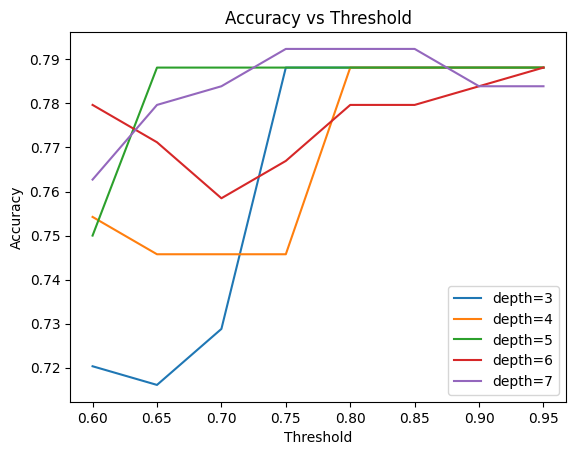


Best configuration:
Depth: 7
Threshold: 0.7500000000000001
Accuracy: 0.7924

Final training with optimal configuration...

Final classification report:
                 precision    recall  f1-score   support

     CLINGO-AMO       0.94      0.96      0.95        46
EOCLINGO-INF-MR       0.80      0.78      0.79       111
     EOCLINGO-L       0.70      0.71      0.70        79

       accuracy                           0.79       236
      macro avg       0.81      0.82      0.81       236
   weighted avg       0.79      0.79      0.79       236


Final accuracy: 79.24%
Tree usage: 64.4%
Oracle usage: 35.6%

Model saved with optimal configuration!


In [32]:
#eo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings
import joblib

warnings.filterwarnings('ignore')

path_eo_train = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/training_dataset_eo.csv'
path_eo_test  = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/testing_dataset_eo.csv'

df_train = pd.read_csv(path_eo_train)
df_test = pd.read_csv(path_eo_test)
df_all = pd.concat([df_train, df_test], ignore_index=True)

df_clean = df_all[df_all['best_config'] != 'TIMEOUT'].copy()

MIN_INSTANCES = 50
valid_classes = df_clean['best_config'].value_counts()
valid_classes = valid_classes[valid_classes >= MIN_INSTANCES].index
df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]

if 'span' in df_clean.columns:
    df_clean['span_ratio'] = np.where(df_clean['bound'] > 0, df_clean['span'] / df_clean['bound'], 0)
    df_clean['span_log'] = np.log1p(df_clean['span'])

features_eo = [
    'bound', 'C2_sum', 'tightness', 'f_horn', 'a', 'f1', 'r', 'n_facts', 'f2', 
    'C3_minps', 'span_ratio', 'minps_ratio', 'span_log'
]

valid_features = [f for f in features_eo if f in df_clean.columns]

X = df_clean[valid_features]
y_raw = df_clean['best_config']

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Training Oracle (XGBoost)...")

sample_weights = compute_sample_weight('balanced', y_train)

if 'EOCLINGO-L' in le.classes_:
    l_idx = le.transform(['EOCLINGO-L'])[0]
    sample_weights[y_train == l_idx] *= 1.8

xgb_oracle = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_oracle.fit(X_train, y_train, sample_weight=sample_weights)

def predict_cascata(X_data, model_triage, model_oracolo, soglia_confidenza=0.75):
    predizioni_finali = []
    contatore_albero = 0
    contatore_oracolo = 0
    
    probabilita_albero = model_triage.predict_proba(X_data)
    confidenza_massima = np.max(probabilita_albero, axis=1)
    
    scelte_albero = model_triage.predict(X_data)
    scelte_oracolo = model_oracolo.predict(X_data)
    
    for i in range(len(X_data)):
        if confidenza_massima[i] >= soglia_confidenza:
            predizioni_finali.append(scelte_albero[i])
            contatore_albero += 1
        else:
            predizioni_finali.append(scelte_oracolo[i])
            contatore_oracolo += 1
            
    return np.array(predizioni_finali), contatore_albero, contatore_oracolo

depth_values = [3, 4, 5, 6, 7]
soglie = np.arange(0.60, 0.96, 0.05)

risultati = []

print("\nSearching for best configuration...\n")

for depth in depth_values:
    
    dt_triage = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    )
    dt_triage.fit(X_train, y_train)
    
    for soglia in soglie:
        
        y_pred, uso_albero, uso_oracolo = predict_cascata(
            X_test, dt_triage, xgb_oracle, soglia_confidenza=soglia
        )
        
        acc = accuracy_score(y_test, y_pred)
        perc_albero = uso_albero / len(X_test)
        
        risultati.append({
            'depth': depth,
            'threshold': soglia,
            'accuracy': acc,
            'tree_usage': perc_albero
        })

df_risultati = pd.DataFrame(risultati)
df_sorted = df_risultati.sort_values(by='accuracy', ascending=False)

print("\nTop configurations:")
print(df_sorted.head(10))

plt.figure()

for depth in depth_values:
    subset = df_risultati[df_risultati['depth'] == depth]
    plt.plot(subset['threshold'], subset['accuracy'], label=f'depth={depth}')

plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Threshold")
plt.legend()
plt.show()

best = df_sorted.iloc[0]

BEST_DEPTH = int(best['depth'])
BEST_THRESHOLD = float(best['threshold'])

print("\nBest configuration:")
print(f"Depth: {BEST_DEPTH}")
print(f"Threshold: {BEST_THRESHOLD}")
print(f"Accuracy: {best['accuracy']:.4f}")

print("\nFinal training with optimal configuration...")

dt_final = DecisionTreeClassifier(
    max_depth=BEST_DEPTH,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

dt_final.fit(X_train, y_train)

y_pred_final, uso_albero, uso_oracolo = predict_cascata(
    X_test, dt_final, xgb_oracle, soglia_confidenza=BEST_THRESHOLD
)

y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred_final)

print("\nFinal classification report:")
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))

acc_final = accuracy_score(y_test, y_pred_final)

print(f"\nFinal accuracy: {acc_final*100:.2f}%")
print(f"Tree usage: {(uso_albero/len(X_test))*100:.1f}%")
print(f"Oracle usage: {(uso_oracolo/len(X_test))*100:.1f}%")

ecosistema_cascata = {
    'modello_triage': dt_final,
    'modello_oracolo': xgb_oracle,
    'label_encoder': le,
    'soglia_confidenza': BEST_THRESHOLD,
    'feature_names': valid_features,
    'tipo_modello': 'optimized_cascaded_EO'
}

joblib.dump(ecosistema_cascata, '/kaggle/working/optimized_cascaded_model_EO.joblib')

print("\nModel saved with optimal configuration!")

In [ ]:
# cascade with foldr++ and xgboost with different ratio values

In [35]:
#amo
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings
import joblib

warnings.filterwarnings('ignore')

try:
    from foldrpp import Foldrpp
except ImportError:
    raise ImportError("FOLD-R++ not found. Install using: pip install foldrpp")


class FoldRPPCascade:
    def __init__(self, ratio=0.5):
        self.ratio = ratio
        self.models = {}
        self.classes_ = None

    def _prepare_feature_lists(self, X):
        str_attrs, num_attrs = [], []
        for col in X.columns:
            if X[col].dtype == 'object' or X[col].dtype.name == 'category':
                str_attrs.append(col)
            else:
                num_attrs.append(col)
        return str_attrs, num_attrs

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        self.classes_ = np.unique(y)
        str_attrs, num_attrs = self._prepare_feature_lists(X)

        for class_val in self.classes_:
            print(f"Training FOLD-R++ rules for class '{class_val}'")

            y_binary = (y == class_val).astype(int)

            model = Foldrpp(str_attrs, num_attrs, 'label', 1)
            data = X.copy()
            data['label'] = y_binary

            model.fit(data.to_dict(orient='records'), ratio=self.ratio)
            self.models[class_val] = model

        return self

    def predict_proba(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        probas = np.zeros((n_samples, n_classes))

        for i in range(n_samples):
            sample = X.iloc[[i]].copy()
            sample['label'] = 0
            record = sample.to_dict(orient='records')

            scores = {}

            for j, class_val in enumerate(self.classes_):
                pred = self.models[class_val].predict(record)[0]
                scores[j] = 1 if str(pred) in ['1', '1.0', 'True'] else 0

            if sum(scores.values()) > 0:
                best = max(scores, key=scores.get)
                probas[i, best] = 1.0
            else:
                probas[i, :] = 1.0 / n_classes

        return probas

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


path_amo_train = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/training_dataset_amo.csv'
path_amo_test = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/testing_dataset_amo.csv'

df_train = pd.read_csv(path_amo_train)
df_test = pd.read_csv(path_amo_test)
df_all = pd.concat([df_train, df_test], ignore_index=True)

df_clean = df_all[df_all['best_config'] != 'TIMEOUT'].copy()

MIN_INSTANCES = 50
valid_classes = df_clean['best_config'].value_counts()
valid_classes = valid_classes[valid_classes >= MIN_INSTANCES].index
df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]

features_amo = [
    'bound', 'C2_sum', 'tightness', 'f_horn', 'a', 'f1', 'r', 'n_facts', 'f2',
    'C1_mps', 'rho', 'mps_ratio'
]

valid_features = [f for f in features_amo if f in df_clean.columns]

X = df_clean[valid_features]
y_raw = df_clean['best_config']

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Training oracle model (XGBoost)...")

sample_weights = compute_sample_weight('balanced', y_train)

if 'AMOCLINGO-L' in le.classes_:
    l_idx = le.transform(['AMOCLINGO-L'])[0]
    sample_weights[y_train == l_idx] *= 1.8

xgb_oracle = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_oracle.fit(X_train, y_train, sample_weight=sample_weights)


def predict_cascade(X_data, triage_model, oracle_model, threshold=0.75):
    triage_proba = triage_model.predict_proba(X_data)
    confidence = np.max(triage_proba, axis=1)

    triage_preds = triage_model.predict(X_data)
    oracle_preds = oracle_model.predict(X_data)

    final_preds = np.where(confidence >= threshold, triage_preds, oracle_preds)

    triage_usage = np.sum(confidence >= threshold)
    oracle_usage = len(X_data) - triage_usage

    return final_preds, triage_usage, oracle_usage


ratio_values = [0.3, 0.5, 0.7]
threshold = 0.75

results = []

print("Searching best FOLD-R++ configuration...\n")

for r in ratio_values:
    print(f"Training FOLD-R++ with ratio={r}")

    triage = FoldRPPCascade(ratio=r)
    triage.fit(X_train, y_train)

    y_pred, triage_used, oracle_used = predict_cascade(
        X_test, triage, xgb_oracle, threshold
    )

    acc = accuracy_score(y_test, y_pred)

    results.append({
        'ratio': r,
        'accuracy': acc,
        'triage_usage': triage_used / len(X_test)
    })

df_results = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)

print("\nTop configurations:")
print(df_results)

best = df_results.iloc[0]
best_ratio = float(best['ratio'])

print(f"\nBest ratio selected: {best_ratio}")

final_triage = FoldRPPCascade(ratio=best_ratio)
final_triage.fit(X_train, y_train)

y_pred_final, triage_used, oracle_used = predict_cascade(
    X_test, final_triage, xgb_oracle, threshold
)

y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred_final)

print("\nFinal classification report:")
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))

print(f"\nFinal accuracy: {accuracy_score(y_test, y_pred_final)*100:.2f}%")
print(f"Triage usage: {(triage_used/len(X_test))*100:.1f}%")
print(f"Oracle usage: {(oracle_used/len(X_test))*100:.1f}%")

ecosystem = {
    'triage_model': final_triage,
    'oracle_model': xgb_oracle,
    'label_encoder': le,
    'threshold': threshold,
    'features': valid_features,
    'type': 'foldrpp_xgboost_cascade_amo'
}

joblib.dump(ecosystem, '/kaggle/working/foldrpp_cascade_amo.joblib')

print("Model successfully saved.")

Training oracle model (XGBoost)...
Searching best FOLD-R++ configuration...

Training FOLD-R++ with ratio=0.3
Training FOLD-R++ rules for class '0'
Training FOLD-R++ rules for class '1'
Training FOLD-R++ rules for class '2'
Training FOLD-R++ with ratio=0.5
Training FOLD-R++ rules for class '0'
Training FOLD-R++ rules for class '1'
Training FOLD-R++ rules for class '2'
Training FOLD-R++ with ratio=0.7
Training FOLD-R++ rules for class '0'
Training FOLD-R++ rules for class '1'
Training FOLD-R++ rules for class '2'

Top configurations:
   ratio  accuracy  triage_usage
0    0.3  0.892405      0.879747
1    0.5  0.892405      0.882911
2    0.7  0.892405      0.882911

Best ratio selected: 0.3
Training FOLD-R++ rules for class '0'
Training FOLD-R++ rules for class '1'
Training FOLD-R++ rules for class '2'

Final classification report:
                  precision    recall  f1-score   support

AMOCLINGO-INF-MR       0.89      0.97      0.93       158
     AMOCLINGO-L       0.89      0.89     

In [34]:
# eo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings
import joblib

warnings.filterwarnings('ignore')

try:
    from foldrpp import Foldrpp
except ImportError:
    raise ImportError("FOLD-R++ not found. Install it using: pip install foldrpp")


class FoldRPPCascade:
    def __init__(self, ratio=0.5):
        self.ratio = ratio
        self.models = {}
        self.classes_ = None

    def _prepare_feature_lists(self, X):
        str_attrs, num_attrs = [], []
        for col in X.columns:
            if X[col].dtype == 'object' or X[col].dtype.name == 'category':
                str_attrs.append(col)
            else:
                num_attrs.append(col)
        return str_attrs, num_attrs

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        self.classes_ = np.unique(y)
        str_attrs, num_attrs = self._prepare_feature_lists(X)

        for class_val in self.classes_:
            print(f"Training FOLD-R++ rules for class '{class_val}'")

            y_binary = (y == class_val).astype(int)

            model = Foldrpp(str_attrs, num_attrs, 'label', 1)
            data_for_fit = X.copy()
            data_for_fit['label'] = y_binary

            model.fit(data_for_fit.to_dict(orient='records'), ratio=self.ratio)
            self.models[class_val] = model

        return self

    def predict_proba(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        probas = np.zeros((n_samples, n_classes))

        for i in range(n_samples):
            sample = X.iloc[[i]].copy()
            sample['label'] = 0
            record = sample.to_dict(orient='records')

            scores = {}

            for j, class_val in enumerate(self.classes_):
                pred = self.models[class_val].predict(record)[0]
                scores[j] = 1 if str(pred) in ['1', '1.0', 'True'] else 0

            if sum(scores.values()) > 0:
                best = max(scores, key=scores.get)
                probas[i, best] = 1.0
            else:
                probas[i, :] = 1.0 / n_classes

        return probas

    def predict(self, X):
        probas = self.predict_proba(X)
        return self.classes_[np.argmax(probas, axis=1)]


path_eo_train = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/training_dataset_eo.csv'
path_eo_test = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/testing_dataset_eo.csv'

df_train = pd.read_csv(path_eo_train)
df_test = pd.read_csv(path_eo_test)
df_all = pd.concat([df_train, df_test], ignore_index=True)

df_clean = df_all[df_all['best_config'] != 'TIMEOUT'].copy()

MIN_INSTANCES = 50
valid_classes = df_clean['best_config'].value_counts()
valid_classes = valid_classes[valid_classes >= MIN_INSTANCES].index
df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]

if 'span' in df_clean.columns:
    df_clean['span_ratio'] = np.where(df_clean['bound'] > 0,
                                      df_clean['span'] / df_clean['bound'], 0)
    df_clean['span_log'] = np.log1p(df_clean['span'])

features_eo = [
    'bound', 'C2_sum', 'tightness', 'f_horn', 'a', 'f1', 'r', 'n_facts', 'f2',
    'C3_minps', 'span_ratio', 'minps_ratio', 'span_log'
]

valid_features = [f for f in features_eo if f in df_clean.columns]

X = df_clean[valid_features]
y_raw = df_clean['best_config']

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Training oracle model (XGBoost)...")

sample_weights = compute_sample_weight('balanced', y_train)

if 'EOCLINGO-L' in le.classes_:
    l_idx = le.transform(['EOCLINGO-L'])[0]
    sample_weights[y_train == l_idx] *= 1.8

xgb_oracle = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_oracle.fit(X_train, y_train, sample_weight=sample_weights)


def predict_cascade(X_data, triage_model, oracle_model, threshold=0.75):
    final_preds = []
    triage_count = 0
    oracle_count = 0

    triage_proba = triage_model.predict_proba(X_data)
    confidence = np.max(triage_proba, axis=1)

    triage_preds = triage_model.predict(X_data)
    oracle_preds = oracle_model.predict(X_data)

    for i in range(len(X_data)):
        if confidence[i] >= threshold:
            final_preds.append(triage_preds[i])
            triage_count += 1
        else:
            final_preds.append(oracle_preds[i])
            oracle_count += 1

    return np.array(final_preds), triage_count, oracle_count


ratio_values = [0.3, 0.5, 0.7]
threshold = 0.75

results = []

print("Searching best configuration for FOLD-R++ cascade...\n")

for ratio in ratio_values:
    print(f"Training FOLD-R++ with ratio={ratio}")

    triage_model = FoldRPPCascade(ratio=ratio)
    triage_model.fit(X_train, y_train)

    y_pred, triage_used, oracle_used = predict_cascade(
        X_test, triage_model, xgb_oracle, threshold
    )

    acc = accuracy_score(y_test, y_pred)

    results.append({
        'ratio': ratio,
        'accuracy': acc,
        'triage_usage': triage_used / len(X_test)
    })

df_results = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)

print("\nTop configurations:")
print(df_results)

best = df_results.iloc[0]
best_ratio = float(best['ratio'])

print(f"\nBest ratio selected: {best_ratio}")

final_triage = FoldRPPCascade(ratio=best_ratio)
final_triage.fit(X_train, y_train)

y_pred_final, triage_used, oracle_used = predict_cascade(
    X_test, final_triage, xgb_oracle, threshold
)

y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred_final)

print("\nFinal classification report:")
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))

final_acc = accuracy_score(y_test, y_pred_final)

print(f"\nFinal accuracy: {final_acc * 100:.2f}%")
print(f"Triage usage: {(triage_used / len(X_test)) * 100:.1f}%")
print(f"Oracle usage: {(oracle_used / len(X_test)) * 100:.1f}%")

ecosystem = {
    'triage_model': final_triage,
    'oracle_model': xgb_oracle,
    'label_encoder': le,
    'threshold': threshold,
    'features': valid_features,
    'type': 'foldrpp_xgboost_cascade_eo'
}

joblib.dump(ecosystem, '/kaggle/working/foldrpp_cascade_eo.joblib')

print("\nModel successfully saved.")

Training oracle model (XGBoost)...
Searching best configuration for FOLD-R++ cascade...

Training FOLD-R++ with ratio=0.3
Training FOLD-R++ rules for class '0'
Training FOLD-R++ rules for class '1'
Training FOLD-R++ rules for class '2'
Training FOLD-R++ with ratio=0.5
Training FOLD-R++ rules for class '0'
Training FOLD-R++ rules for class '1'
Training FOLD-R++ rules for class '2'
Training FOLD-R++ with ratio=0.7
Training FOLD-R++ rules for class '0'
Training FOLD-R++ rules for class '1'
Training FOLD-R++ rules for class '2'

Top configurations:
   ratio  accuracy  triage_usage
1    0.5  0.788136      0.750000
0    0.3  0.783898      0.766949
2    0.7  0.766949      0.809322

Best ratio selected: 0.5
Training FOLD-R++ rules for class '0'
Training FOLD-R++ rules for class '1'
Training FOLD-R++ rules for class '2'

Final classification report:
                 precision    recall  f1-score   support

     CLINGO-AMO       0.88      0.91      0.89        46
EOCLINGO-INF-MR       0.77      

In [ ]:
# usage of an automl with different level 1 and level 2 -> goal: find the best combination of selectors
# preserving interpretabilty, speed and accuracy

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings
import joblib
import time

warnings.filterwarnings('ignore')

class FoldRPPCascade:
    def __init__(self, ratio=0.5): 
        self.ratio = ratio
        self.models = {}      
        self.classes_ = None

    def _prepare_feature_lists(self, X):
        str_attrs, num_attrs = [], []
        for col in X.columns:
            if X[col].dtype == 'object' or X[col].dtype.name == 'category':
                str_attrs.append(col)
            else:
                num_attrs.append(col)
        return str_attrs, num_attrs

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame): X = pd.DataFrame(X)
        self.classes_ = np.unique(y)
        str_attrs, num_attrs = self._prepare_feature_lists(X)

        for class_val in self.classes_:
            y_binary = (y == class_val).astype(int)
            model = Foldrpp(str_attrs, num_attrs, 'label', 1)
            data_for_fit = X.copy()
            data_for_fit['label'] = y_binary
            model.fit(data_for_fit.to_dict(orient='records'), ratio=self.ratio)
            self.models[class_val] = model
        return self

    def predict(self, X):
        probas = self.predict_proba(X)
        return self.classes_[np.argmax(probas, axis=1)]

    def predict_proba(self, X):
        if not isinstance(X, pd.DataFrame): X = pd.DataFrame(X)
        n_samples, n_classes = X.shape[0], len(self.classes_)
        probas = np.zeros((n_samples, n_classes))
        
        for idx in range(n_samples):
            sample = X.iloc[[idx]].copy()
            sample['label'] = 0 
            sample_record = sample.to_dict(orient='records')
            scores = {i: (1 if str(self.models[c].predict(sample_record)[0]) in ['1', '1.0', 'True'] else 0) 
                      for i, c in enumerate(self.classes_)}
            
            if sum(scores.values()) > 0:
                probas[idx, max(scores, key=scores.get)] = 1.0
            else:
                probas[idx, :] = 1.0 / n_classes
        return probas

print("Loading AMO data...")
path_amo_train = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/training_dataset_amo.csv'
path_amo_test  = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/amo/testing_dataset_amo.csv'

df_train = pd.read_csv(path_amo_train)
df_test = pd.read_csv(path_amo_test)
df_all = pd.concat([df_train, df_test], ignore_index=True)

df_clean = df_all[df_all['best_config'] != 'TIMEOUT'].copy()
MIN_INSTANCES = 50
valid_classes = df_clean['best_config'].value_counts()
valid_classes = valid_classes[valid_classes >= MIN_INSTANCES].index
df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]

features_amo = ['bound', 'C2_sum', 'tightness', 'f_horn', 'a', 'f1', 'r', 'n_facts', 'f2', 'C1_mps', 'rho', 'mps_ratio']
valid_features = [f for f in features_amo if f in df_clean.columns]

X, y_raw = df_clean[valid_features], df_clean['best_config']
le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

sample_weights = compute_sample_weight('balanced', y_train)
if 'AMOCLINGO-L' in le.classes_:
    sample_weights[y_train == le.transform(['AMOCLINGO-L'])[0]] *= 1.8

print("\nConfiguring AutoML search space...")
candidati_l1 = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'DecisionTree (d=4)': DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42),
    'DecisionTree (d=6)': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'RandomForest (Shallow)': RandomForestClassifier(n_estimators=30, max_depth=5, class_weight='balanced', random_state=42),
    'KNN (k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='uniform')),
    'SVM (Linear)': make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42))
}

try:
    from foldrpp import Foldrpp
    candidati_l1['FoldR++ (Ratio=0.3)'] = FoldRPPCascade(ratio=0.3)
except ImportError:
    print("⚠️ FOLD-R++ library not found.")

candidati_l2 = {
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1),
    'RandomForest (Deep)': RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1),
    'KNN (Distance, k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance')),
    'SVM (RBF)': make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42))
}

soglie_confidenza = [0.65, 0.75, 0.85, 0.90]

print("\n🚀 STARTING CASCADE AUTOML SEARCH (AMO Dataset)...")
start_time, risultati_automl = time.time(), []

for nome_l2, modello_l2 in candidati_l2.items():
    print(f"\n[Level 2] Training Oracle: {nome_l2}...")
    fit_params = {'sample_weight': sample_weights} if nome_l2 in ['XGBoost', 'LightGBM'] else {}
    modello_l2.fit(X_train, y_train, **fit_params)
    scelte_oracolo = modello_l2.predict(X_test)
    
    for nome_l1, modello_l1 in candidati_l1.items():
        print(f"  ↳ Testing Triage (L1): {nome_l1}")
        modello_l1.fit(X_train, y_train)
        
        prob_l1 = modello_l1.predict_proba(X_test)
        conf_l1, pred_l1 = np.max(prob_l1, axis=1), modello_l1.predict(X_test)
        soglie = [0.75] if 'FoldR++' in nome_l1 else soglie_confidenza
        
        for s in soglie:
            final_p = np.where(conf_l1 >= s, pred_l1, scelte_oracolo)
            risultati_automl.append({
                'Triage_L1': nome_l1, 'Oracle_L2': nome_l2, 'Threshold': s,
                'Accuracy': accuracy_score(y_test, final_p),
                'L1_Usage_perc': (np.sum(conf_l1 >= s) / len(X_test)) * 100
            })

df_automl = pd.DataFrame(risultati_automl).sort_values(by=['Accuracy', 'L1_Usage_perc'], ascending=[False, False])

print("\n" + "="*60 + f"\n⏱️ Search completed in {time.time() - start_time:.1f}s.\n🏆 CASCADE AUTOML LEADERBOARD:\n" + "="*60)
print(df_automl.head(10).to_string(index=False))

best = df_automl.iloc[0]
print(f"\n👑 FINAL WINNING MODEL: L1={best['Triage_L1']}, L2={best['Oracle_L2']}, Threshold={best['Threshold']:.2f}")

best_l1, best_l2 = candidati_l1[best['Triage_L1']], candidati_l2[best['Oracle_L2']]
p_l1 = best_l1.predict_proba(X_test)
y_final = np.where(np.max(p_l1, axis=1) >= best['Threshold'], best_l1.predict(X_test), best_l2.predict(X_test))

print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(le.inverse_transform(y_test), le.inverse_transform(y_final), zero_division=0))
print(f"\n🎯 Final Accuracy: {best['Accuracy']*100:.2f}% | L1 Usage: {best['L1_Usage_perc']:.1f}%")

joblib.dump({'triage': best_l1, 'oracle': best_l2, 'le': le, 'threshold': best['Threshold'], 'features': valid_features}, '/kaggle/working/modello_automl_cascata_AMO.joblib')
print("\n📦 Model saved successfully!")

Loading AMO data...

Configuring AutoML search space...

🚀 STARTING CASCADE AUTOML SEARCH (AMO Dataset)...

[Level 2] Training Oracle: XGBoost...
  ↳ Testing Triage (L1): LogisticRegression
  ↳ Testing Triage (L1): DecisionTree (d=4)
  ↳ Testing Triage (L1): DecisionTree (d=6)
  ↳ Testing Triage (L1): RandomForest (Shallow)
  ↳ Testing Triage (L1): KNN (k=5)
  ↳ Testing Triage (L1): SVM (Linear)
  ↳ Testing Triage (L1): FoldR++ (Ratio=0.3)

[Level 2] Training Oracle: LightGBM...
  ↳ Testing Triage (L1): LogisticRegression
  ↳ Testing Triage (L1): DecisionTree (d=4)
  ↳ Testing Triage (L1): DecisionTree (d=6)
  ↳ Testing Triage (L1): RandomForest (Shallow)
  ↳ Testing Triage (L1): KNN (k=5)
  ↳ Testing Triage (L1): SVM (Linear)
  ↳ Testing Triage (L1): FoldR++ (Ratio=0.3)

[Level 2] Training Oracle: RandomForest (Deep)...
  ↳ Testing Triage (L1): LogisticRegression
  ↳ Testing Triage (L1): DecisionTree (d=4)
  ↳ Testing Triage (L1): DecisionTree (d=6)
  ↳ Testing Triage (L1): RandomFore

In [36]:
# eo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings
import joblib
import time

warnings.filterwarnings('ignore')

class FoldRPPCascade:
    def __init__(self, ratio=0.5): 
        self.ratio = ratio
        self.models = {}      
        self.classes_ = None

    def _prepare_feature_lists(self, X):
        str_attrs, num_attrs = [], []
        for col in X.columns:
            if X[col].dtype == 'object' or X[col].dtype.name == 'category':
                str_attrs.append(col)
            else:
                num_attrs.append(col)
        return str_attrs, num_attrs

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame): X = pd.DataFrame(X)
        self.classes_ = np.unique(y)
        str_attrs, num_attrs = self._prepare_feature_lists(X)

        for class_val in self.classes_:
            y_binary = (y == class_val).astype(int)
            model = Foldrpp(str_attrs, num_attrs, 'label', 1)
            
            data_for_fit = X.copy()
            data_for_fit['label'] = y_binary
            data_records = data_for_fit.to_dict(orient='records')
            
            model.fit(data_records, ratio=self.ratio)
            self.models[class_val] = model
            
        return self

    def predict(self, X):
        probas = self.predict_proba(X)
        best_indices = np.argmax(probas, axis=1)
        return self.classes_[best_indices]

    def predict_proba(self, X):
        if not isinstance(X, pd.DataFrame): X = pd.DataFrame(X)
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        probas = np.zeros((n_samples, n_classes))
        
        for idx in range(n_samples):
            sample = X.iloc[[idx]].copy()
            sample['label'] = 0 
            sample_record = sample.to_dict(orient='records')
            
            scores = {}
            for class_idx, class_val in enumerate(self.classes_):
                pred = self.models[class_val].predict(sample_record)[0]
                scores[class_idx] = 1 if str(pred) in ['1', '1.0', 'True'] else 0
            
            if sum(scores.values()) > 0:
                best_idx = max(scores, key=scores.get)
                probas[idx, best_idx] = 1.0
            else:
                probas[idx, :] = 1.0 / n_classes
                
        return probas

print("Loading EO data...")
path_eo_train = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/training_dataset_eo.csv'
path_eo_test  = '/kaggle/input/datasets/meganmacri/dataset-amo-eo/final_dataset/eo/testing_dataset_eo.csv'

df_train = pd.read_csv(path_eo_train)
df_test = pd.read_csv(path_eo_test)
df_all = pd.concat([df_train, df_test], ignore_index=True)

df_clean = df_all[df_all['best_config'] != 'TIMEOUT'].copy()
MIN_INSTANCES = 50
valid_classes = df_clean['best_config'].value_counts()
valid_classes = valid_classes[valid_classes >= MIN_INSTANCES].index
df_clean = df_clean[df_clean['best_config'].isin(valid_classes)]

if 'span' in df_clean.columns:
    df_clean['span_ratio'] = np.where(df_clean['bound'] > 0, df_clean['span'] / df_clean['bound'], 0)
    df_clean['span_log'] = np.log1p(df_clean['span'])

features_eo = [
    'bound', 'C2_sum', 'tightness', 'f_horn', 'a', 'f1', 'r', 'n_facts', 'f2', 
    'C3_minps', 'span_ratio', 'minps_ratio', 'span_log'
]

valid_features = [f for f in features_eo if f in df_clean.columns]
X = df_clean[valid_features]
y_raw = df_clean['best_config']

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

sample_weights = compute_sample_weight('balanced', y_train)
if 'EOCLINGO-L' in le.classes_:
    l_idx = le.transform(['EOCLINGO-L'])[0]
    sample_weights[y_train == l_idx] *= 1.8

print("\nConfiguring AutoML search space...")
candidati_l1 = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'DecisionTree (d=4)': DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42),
    'DecisionTree (d=6)': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'RandomForest (Shallow)': RandomForestClassifier(n_estimators=30, max_depth=5, class_weight='balanced', random_state=42),
    'KNN (k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='uniform')),
    'SVM (Linear)': make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42))
}

try:
    from foldrpp import Foldrpp
    candidati_l1['FoldR++ (Ratio=0.5)'] = FoldRPPCascade(ratio=0.5)
except ImportError:
    print("⚠️ FOLD-R++ not found. Skipping it in candidates.")

candidati_l2 = {
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1),
    'RandomForest (Deep)': RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1),
    'KNN (Distance, k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, weights='distance')),
    'SVM (RBF)': make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42))
}

soglie_confidenza = [0.65, 0.75, 0.85, 0.90]

print("\n🚀 STARTING CASCADE AUTOML SEARCH...")
start_time = time.time()
risultati_automl = []

for nome_l2, modello_l2 in candidati_l2.items():
    print(f"\n[Level 2] Training Oracle: {nome_l2}...")
    fit_params = {}
    if nome_l2 in ['XGBoost', 'LightGBM']:
        fit_params['sample_weight'] = sample_weights
        
    modello_l2.fit(X_train, y_train, **fit_params)
    oracle_preds = modello_l2.predict(X_test)
    
    for nome_l1, modello_l1 in candidati_l1.items():
        print(f"  ↳ Testing Triage (L1): {nome_l1}")
        modello_l1.fit(X_train, y_train)
        
        is_fold = 'FoldR++' in nome_l1
        thresholds_to_test = [0.75] if is_fold else soglie_confidenza
        
        l1_probas = modello_l1.predict_proba(X_test)
        l1_max_conf = np.max(l1_probas, axis=1)
        l1_preds = modello_l1.predict(X_test)
        
        for threshold in thresholds_to_test:
            use_l1_mask = l1_max_conf >= threshold
            final_predictions = np.where(use_l1_mask, l1_preds, oracle_preds)
            
            l1_usage = (np.sum(use_l1_mask) / len(X_test)) * 100
            acc = accuracy_score(y_test, final_predictions)
            
            risultati_automl.append({
                'Triage_L1': nome_l1,
                'Oracle_L2': nome_l2,
                'Threshold': threshold,
                'Accuracy': acc,
                'L1_Usage_perc': l1_usage
            })

df_automl = pd.DataFrame(risultati_automl)
df_automl_sorted = df_automl.sort_values(by=['Accuracy', 'L1_Usage_perc'], ascending=[False, False])

print("\n" + "="*60)
print(f"⏱️ Search completed in {time.time() - start_time:.1f} seconds.")
print("🏆 CASCADE AUTOML LEADERBOARD (Top 10 Combinations):")
print("="*60)
print(df_automl_sorted.head(10).to_string(index=False))

winner = df_automl_sorted.iloc[0]
print("\n👑 BUILDING FINAL WINNING MODEL:")
print(f"Level 1: {winner['Triage_L1']}")
print(f"Level 2: {winner['Oracle_L2']}")
print(f"Threshold: {winner['Threshold']:.2f}")

best_l1_model = candidati_l1[winner['Triage_L1']]
best_l2_model = candidati_l2[winner['Oracle_L2']]
best_threshold = winner['Threshold']

l1_probas = best_l1_model.predict_proba(X_test)
l1_max_conf = np.max(l1_probas, axis=1)
l1_preds = best_l1_model.predict(X_test)
oracle_preds = best_l2_model.predict(X_test)

use_l1_mask = l1_max_conf >= best_threshold
y_pred_final = np.where(use_l1_mask, l1_preds, oracle_preds)

y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred_final)

print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))

print(f"\n🎯 Final Accuracy: {winner['Accuracy']*100:.2f}%")
print(f"Instances resolved by Triage (L1) : {winner['L1_Usage_perc']:.1f}%")
print(f"Instances delegated to Oracle (L2): {100 - winner['L1_Usage_perc']:.1f}%")

final_ecosystem = {
    'triage_model': best_l1_model,
    'oracle_model': best_l2_model,
    'label_encoder': le,
    'confidence_threshold': best_threshold,
    'feature_names': valid_features,
    'model_type': 'automl_cascade_EO',
    'metadata': winner.to_dict()
}

joblib.dump(final_ecosystem, '/kaggle/working/modello_automl_cascata_EO.joblib')
print("\n📦 Model successfully saved!")

Loading EO data...

Configuring AutoML search space...

🚀 STARTING CASCADE AUTOML SEARCH...

[Level 2] Training Oracle: XGBoost...
  ↳ Testing Triage (L1): LogisticRegression
  ↳ Testing Triage (L1): DecisionTree (d=4)
  ↳ Testing Triage (L1): DecisionTree (d=6)
  ↳ Testing Triage (L1): RandomForest (Shallow)
  ↳ Testing Triage (L1): KNN (k=5)
  ↳ Testing Triage (L1): SVM (Linear)
  ↳ Testing Triage (L1): FoldR++ (Ratio=0.5)

[Level 2] Training Oracle: LightGBM...
  ↳ Testing Triage (L1): LogisticRegression
  ↳ Testing Triage (L1): DecisionTree (d=4)
  ↳ Testing Triage (L1): DecisionTree (d=6)
  ↳ Testing Triage (L1): RandomForest (Shallow)
  ↳ Testing Triage (L1): KNN (k=5)
  ↳ Testing Triage (L1): SVM (Linear)
  ↳ Testing Triage (L1): FoldR++ (Ratio=0.5)

[Level 2] Training Oracle: RandomForest (Deep)...
  ↳ Testing Triage (L1): LogisticRegression
  ↳ Testing Triage (L1): DecisionTree (d=4)
  ↳ Testing Triage (L1): DecisionTree (d=6)
  ↳ Testing Triage (L1): RandomForest (Shallow)
  